<a href="https://colab.research.google.com/github/s0j5i1m5-coder/Colab/blob/main/EDA_%EB%B0%8F_RFM_%EC%82%B0%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import drive

# 구글 드라이브 연결

drive.mount('/content/drive')

# CSV 파일 로드

Customer = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Customer_info.csv")
Discount = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Discount_info.csv")
Marketing = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Marketing_info.csv")
Onlinesales = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Onlinesales_info.csv")
Tax = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Tax_info.csv")

# 확인
display(Onlinesales.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


In [53]:
# ✅ 1️⃣ 나눔 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-coding fonts-nanum-extra

# ✅ 2️⃣ 폰트 캐시 재빌드
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 캐시 삭제
os.system('rm -rf /root/.cache/matplotlib')

# 새 캐시 생성
fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

# ✅ 3️⃣ 기본 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
fonts-nanum-coding is already the newest version (2.5-3).
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.



📊 Customer 데이터 요약

▶️ 데이터 기본 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   고객ID    1468 non-null   object
 1   성별      1468 non-null   object
 2   고객지역    1468 non-null   object
 3   가입기간    1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB
None 

▶️ 결측치 현황
고객ID    0
성별      0
고객지역    0
가입기간    0
dtype: int64 

▶️ 중복 데이터 개수: 0 

▶️ 기초 통계 요약


,가입기간
count,1468.000000
mean,25.912125
std,13.959667
min,2.000000
25%,14.000000
50%,26.000000
75%,38.000000
max,50.000000


,고객ID,성별,고객지역,가입기간
0,USER_1358,남,Chicago,12
1,USER_0190,남,California,43
2,USER_0066,남,Chicago,33


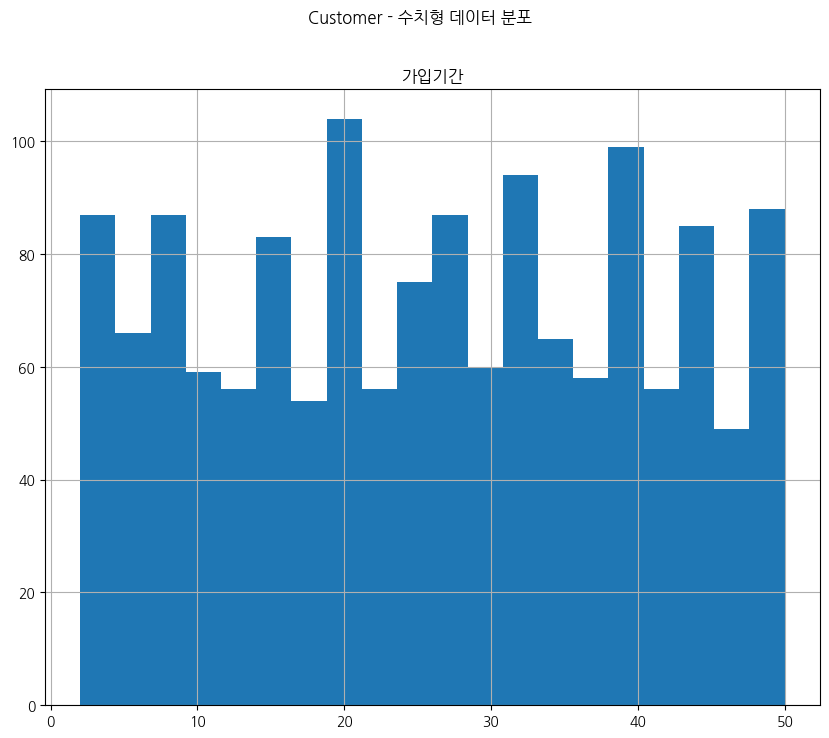


📊 Discount 데이터 요약

▶️ 데이터 기본 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   월       204 non-null    object
 1   제품카테고리  204 non-null    object
 2   쿠폰코드    204 non-null    object
 3   할인율     204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB
None 

▶️ 결측치 현황
월         0
제품카테고리    0
쿠폰코드      0
할인율       0
dtype: int64 

▶️ 중복 데이터 개수: 0 

▶️ 기초 통계 요약


,할인율
count,204.000000
mean,20.000000
std,8.185052
min,10.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,30.000000


,월,제품카테고리,쿠폰코드,할인율
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30


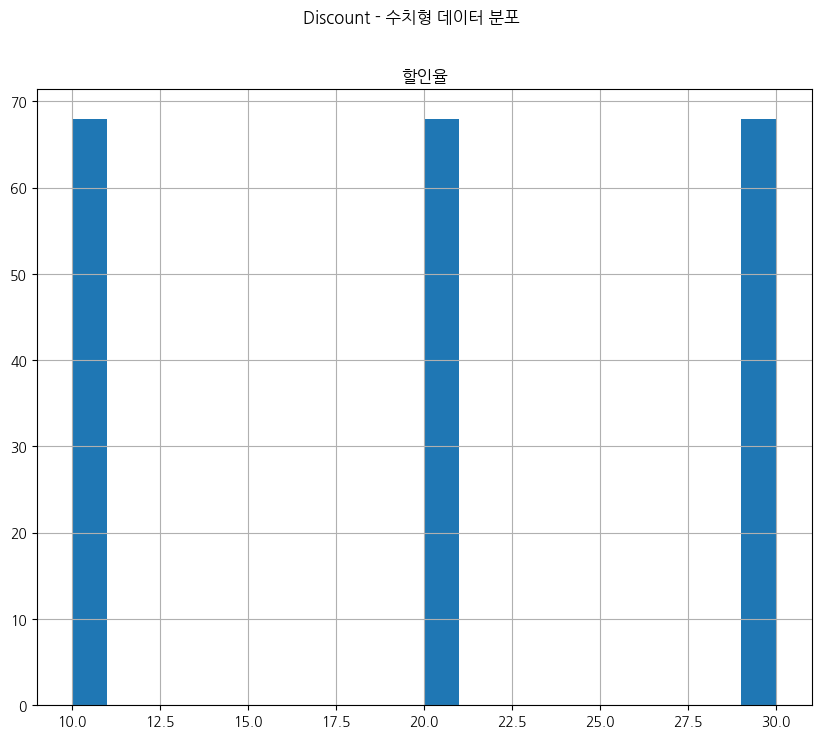


📊 Marketing 데이터 요약

▶️ 데이터 기본 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      365 non-null    datetime64[ns]
 1   오프라인비용  365 non-null    int64         
 2   온라인비용   365 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 8.7 KB
None 

▶️ 결측치 현황
날짜        0
오프라인비용    0
온라인비용     0
dtype: int64 

▶️ 중복 데이터 개수: 0 

▶️ 기초 통계 요약


,날짜,오프라인비용,온라인비용
count,365,365.000000,365.000000
mean,2019-07-02 00:00:00,2843.561644,1905.880740
min,2019-01-01 00:00:00,500.000000,320.250000
25%,2019-04-02 00:00:00,2500.000000,1258.600000
50%,2019-07-02 00:00:00,3000.000000,1881.940000
75%,2019-10-01 00:00:00,3500.000000,2435.120000
max,2019-12-31 00:00:00,5000.000000,4556.930000
std,NaN,952.292448,808.856853


,날짜,오프라인비용,온라인비용
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4500,1576.38


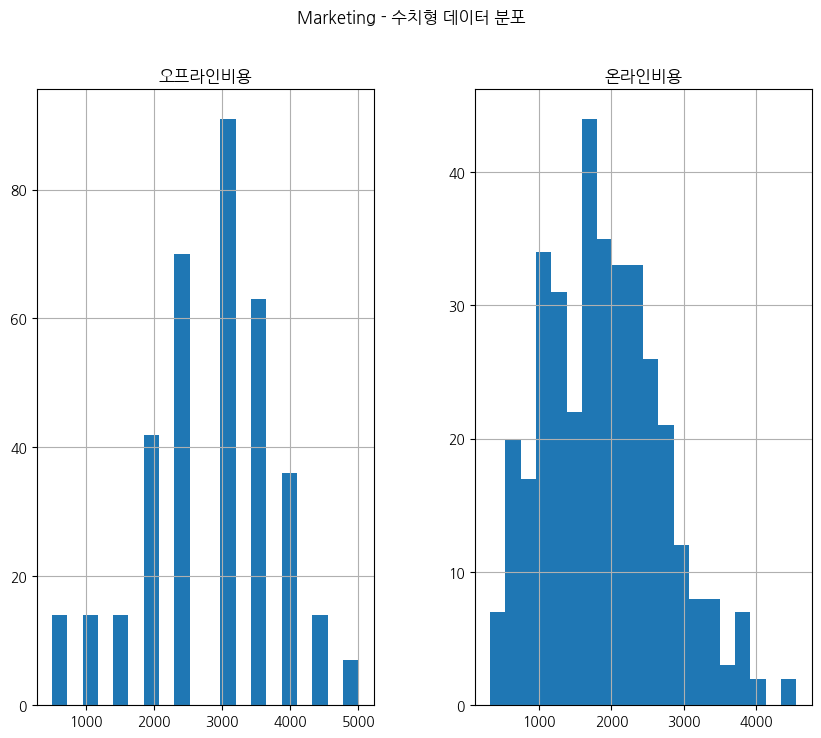


📊 Onlinesales 데이터 요약

▶️ 데이터 기본 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   고객ID    52924 non-null  object        
 1   거래ID    52924 non-null  object        
 2   거래날짜    52924 non-null  datetime64[ns]
 3   제품ID    52924 non-null  object        
 4   제품카테고리  52924 non-null  object        
 5   수량      52924 non-null  int64         
 6   평균금액    52924 non-null  float64       
 7   배송료     52924 non-null  float64       
 8   쿠폰상태    52924 non-null  object        
 9   총 금액    52924 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 4.0+ MB
None 

▶️ 결측치 현황
고객ID      0
거래ID      0
거래날짜      0
제품ID      0
제품카테고리    0
수량        0
평균금액      0
배송료       0
쿠폰상태      0
총 금액      0
dtype: int64 

▶️ 중복 데이터 개수: 0 

▶️ 기초 통계 요약


,거래날짜,수량,평균금액,배송료,총 금액
count,52924,52924.000000,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630,98.772385
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000,4.120000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000,19.590000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000,42.890000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000,129.270000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000,10518.390000
std,NaN,20.104711,64.006882,19.475613,166.441239


,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,총 금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,160.21
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,160.21
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,8.55


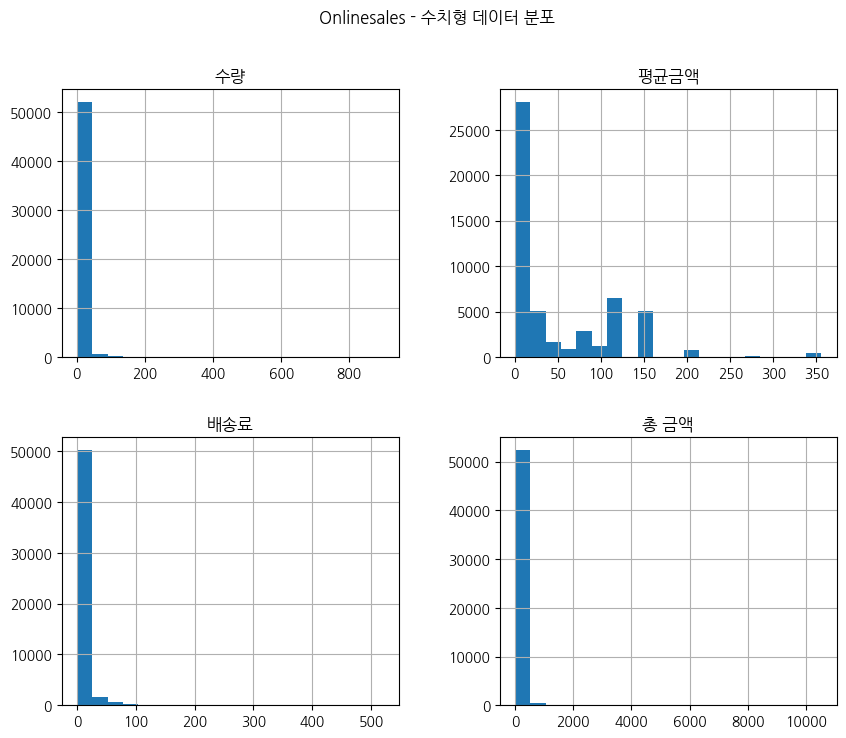


📊 Tax 데이터 요약

▶️ 데이터 기본 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품카테고리  20 non-null     object 
 1   GST     20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes
None 

▶️ 결측치 현황
제품카테고리    0
GST       0
dtype: int64 

▶️ 중복 데이터 개수: 0 

▶️ 기초 통계 요약


,GST
count,20.000000
mean,0.116500
std,0.052443
min,0.050000
25%,0.087500
50%,0.100000
75%,0.180000
max,0.180000


,제품카테고리,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18


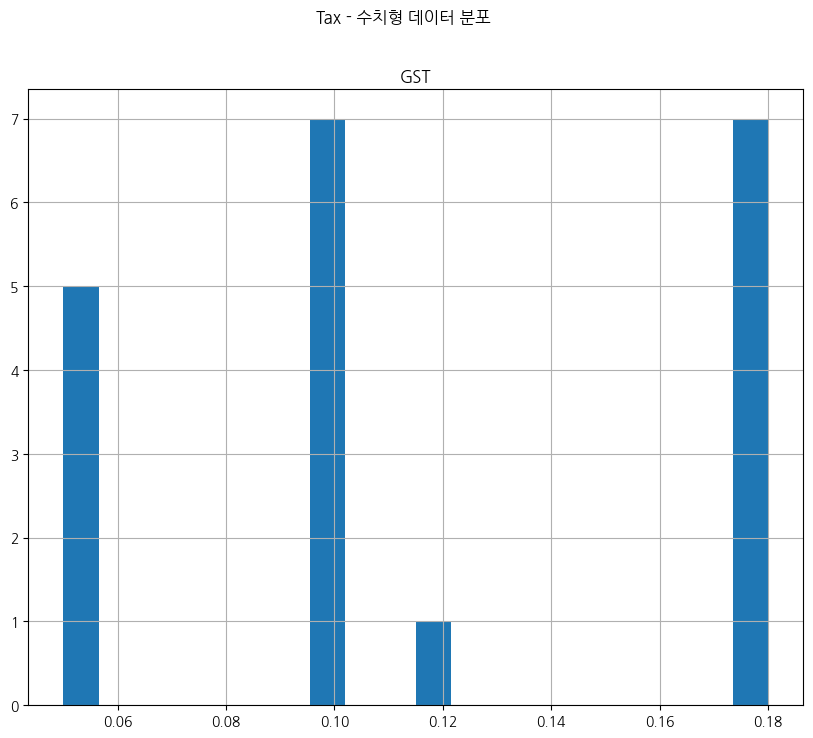

In [50]:
# 한글 폰트 설정

import matplotlib.pyplot as plt
import matplotlib as mpl

# Add the font to the font manager
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# Set the font family
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

datasets = {
    "Customer" : Customer,
    "Discount" : Discount,
    "Marketing" : Marketing,
    "Onlinesales" : Onlinesales,
    "Tax" : Tax
}

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"📊 {name} 데이터 요약")
    print(f"{'='*40}\n")

    # 기본 구조
    print("▶️ 데이터 기본 구조")
    print(df.info(), "\n")

    # 결측치 확인
    print("▶️ 결측치 현황")
    print(df.isnull().sum(), "\n")

    # 중복 행 여부
    print("▶️ 중복 데이터 개수:", df.duplicated().sum(), "\n")

    # 기초 통계
    print("▶️ 기초 통계 요약")
    display(df.describe())

    # 상위 3행 미리보기
    display(df.head(3))

    # 수치형 컬럼 분포 시각화
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    if len(numeric_cols) > 0:
        df[numeric_cols].hist(figsize=(10,8), bins=20)
        plt.suptitle(f'{name} - 수치형 데이터 분포')
        plt.show()

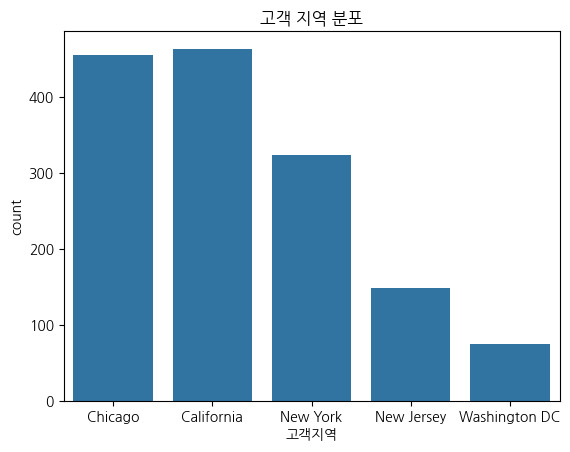

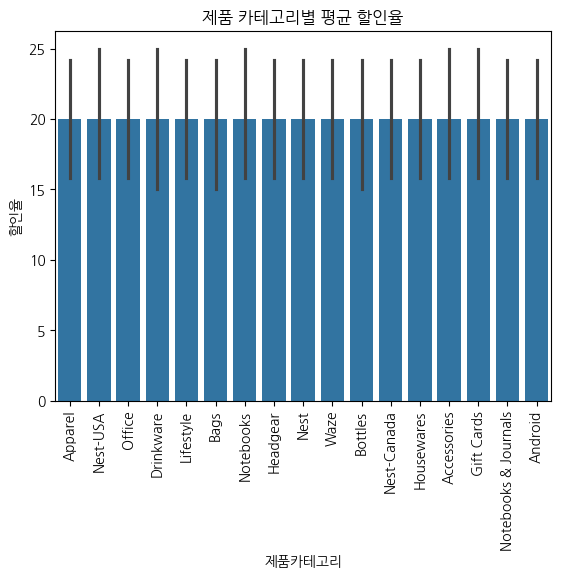

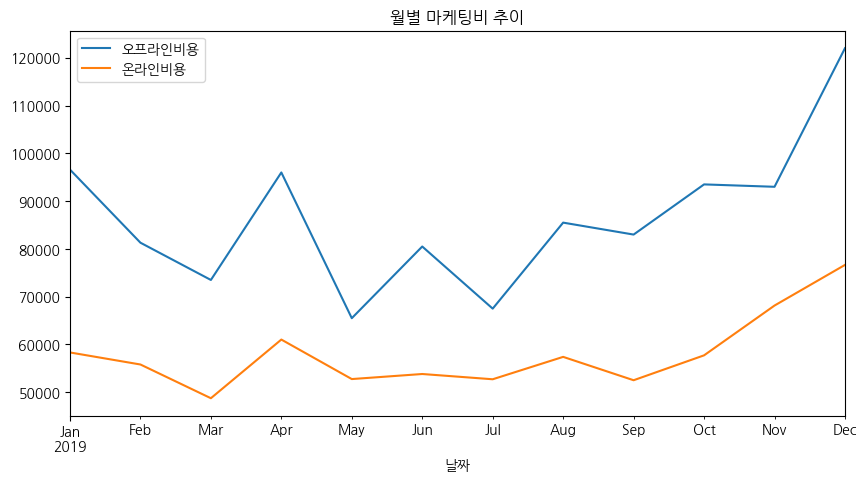

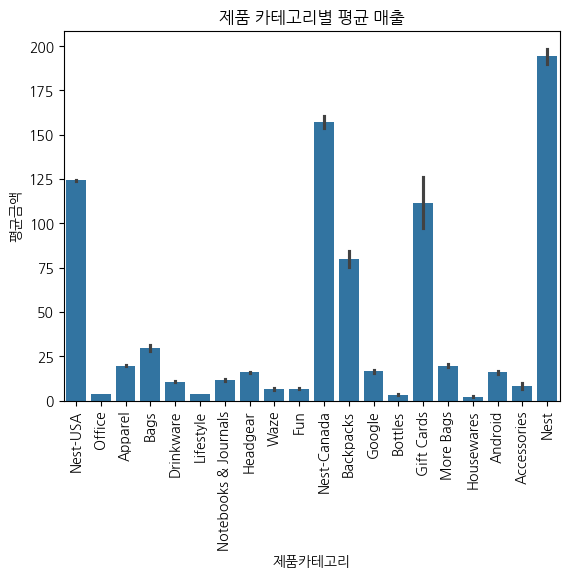

In [55]:
# ① 고객 지역 분포
sns.countplot(x='고객지역', data=Customer)
plt.title('고객 지역 분포')
plt.show()

# ② 카테고리별 평균 할인율
sns.barplot(x='제품카테고리', y='할인율', data=Discount)
plt.title('제품 카테고리별 평균 할인율')
plt.xticks(rotation=90)
plt.show()

# ③ 월별 마케팅비 추이
Marketing['날짜'] = pd.to_datetime(Marketing['날짜'])
Marketing.groupby(Marketing['날짜'].dt.to_period('M'))[['오프라인비용','온라인비용']].sum().plot(figsize=(10,5))
plt.title('월별 마케팅비 추이')
plt.show()

# ④ Onlinesales - 제품 카테고리별 평균 매출
sns.barplot(x='제품카테고리', y='평균금액', data=Onlinesales)
plt.title('제품 카테고리별 평균 매출')
plt.xticks(rotation=90)
plt.show()

RFM 산출

In [27]:
# 날짜 형식 변환 & 기준일 설정

 Onlinesales['거래날짜'] = pd.to_datetime(Onlinesales['거래날짜'])
 today = Onlinesales['거래날짜'].max() + pd.Timedelta(days=1)

In [28]:
# 구매 금액 계산

 Onlinesales['총 금액'] = (Onlinesales['수량'] * Onlinesales['평균금액']) + Onlinesales['배송료']

In [32]:
 # RFM 분석
 # 고객별 RFM 값 산출

rfm = Onlinesales.groupby('고객ID').agg({
    '거래날짜' : lambda x : (today - x.max()).days, #Recency
    '거래ID' : 'nunique', #Frequency
    '총 금액' : 'sum' #Monetary
}).rename(columns={'거래날짜': 'Recency', '거래ID': 'Frequency', '총 금액': 'Monetary'}).reset_index()

RFM 스코어 및 등급 부여

In [33]:
# 각 지표 점수화 (1~5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# RFM 총점
rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1).astype(int)

# 등급 분류
def assign_membership(score):
    if score >= 14:
        return 'Diamond VIP'
    elif score >= 11:
        return 'Gold 핵심고객'
    elif score >= 8:
        return 'Silver 우수고객'
    elif score >= 5:
        return 'Bronze 일반고객'
    else:
        return 'White 휴면고객'

rfm['Membership'] = rfm['RFM_Score'].apply(assign_membership)
display(rfm.head())

,고객ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Membership
0,USER_0000,108,1,180.99,3,1,1,5,Bronze 일반고객
1,USER_0001,60,31,14500.04,4,5,5,14,Diamond VIP
2,USER_0002,74,8,1639.27,4,2,3,9,Silver 우수고객
3,USER_0003,18,11,1487.95,5,3,3,11,Gold 핵심고객
4,USER_0004,108,13,2079.96,3,3,3,9,Silver 우수고객


결과 시각화

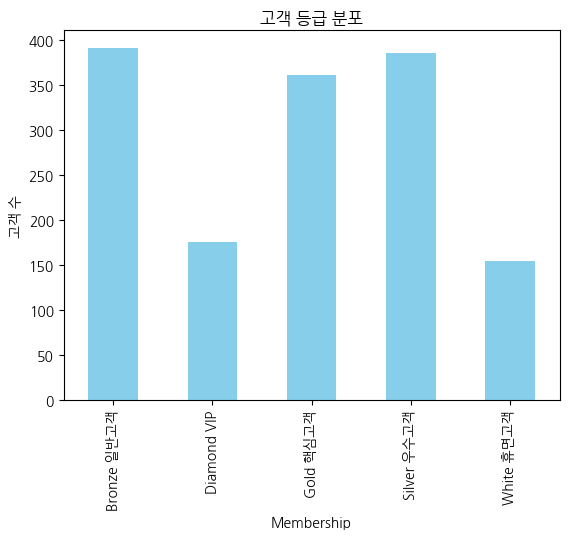

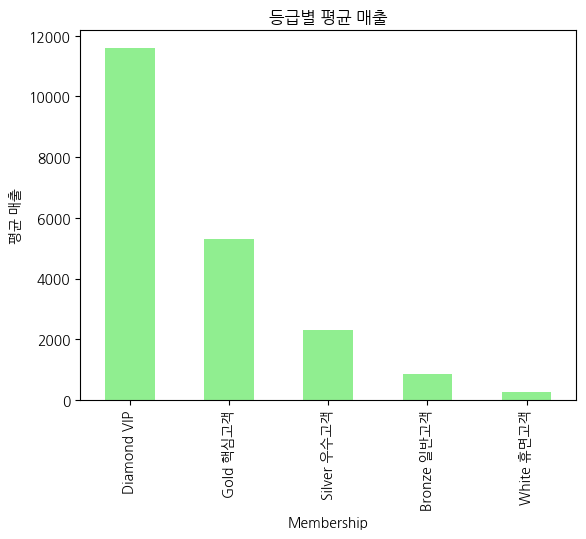

In [44]:
# 등급별 고객 수

rfm['Membership'].value_counts().sort_index().plot(kind='bar',color='skyblue')
plt.title('고객 등급 분포')
plt.xlabel('Membership')
plt.ylabel('고객 수')
plt.show()

# 등급별 평균 매출

rfm.groupby('Membership')['Monetary'].mean().sort_values(ascending=False).plot(kind='bar',color='lightgreen')
plt.title('등급별 평균 매출')
plt.ylabel('평균 매출')
plt.show()

결과 저장

In [48]:
rfm.to_csv("/content/drive/MyDrive/Colab Notebooks/RFM_result.csv", index=False, encoding='utf-8-sig')
print("✅ RFM 분석 완료! 결과 파일이 Colab Notebooks 폴더에 저장되었습니다.")


✅ RFM 분석 완료! 결과 파일이 Colab Notebooks 폴더에 저장되었습니다.
